In [1]:
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

In [2]:
df = pd.read_csv("/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_output_data/all_statistics.csv").set_index(['Unnamed: 0'])
df.head(10)

,hippocampal_layer,metric,p_value,statistical significant?
Unnamed: 0,,,,
0,CA1 SO,overlap_um2,0.322502,No
1,CA1 SO,pearson_cor,0.901023,No
2,CA1 SO,overlap_coeff,0.115381,No
3,CA1 SO,local_peak_colocalized_spots,0.282742,No
4,CA1 SO,presynapse_image_mfi,0.036487,Yes
5,CA1 SO,postsynapse_image_mfi,0.855759,No
6,CA1 SO,pre_puncta_density_per_100_um2,0.572791,No
7,CA1 SO,post_puncta_density_per_100_um2,0.816116,No
8,CA1 SO,pre_staining_area_um2,0.466850,No


In [3]:
df_2 = df.pivot(index="metric", columns="hippocampal_layer", values="p_value")
df_2.head(10)

hippocampal_layer,CA1 SLM,CA1 SO,CA1 SR,CA3 SL,CA3 SO,CA3 SR,DG Hilus,DG ML
metric,,,,,,,,
local_peak_colocalized_spots,0.380834,0.282742,0.335689,0.043143,0.023175,0.047433,0.033101,0.213016
overlap_coeff,0.359423,0.115381,0.182171,0.423335,0.836110,0.179397,0.580358,0.391630
overlap_um2,0.436481,0.322502,0.451097,0.646520,0.846909,0.129066,0.041272,0.612212
pearson_cor,0.927757,0.901023,0.243592,0.584826,0.218832,0.230396,0.565650,0.616919
post_mean_puncta_size_um2,0.789960,0.416695,0.636948,0.338470,0.152173,0.655923,0.276608,0.442502
post_puncta_density_per_100_um2,0.723442,0.816116,0.216605,0.738104,0.518395,0.651935,0.498757,0.984687
post_staining_area_um2,0.782553,0.755015,0.308545,0.954016,0.642750,0.522367,0.998795,0.525695
postsynapse_image_mfi,0.897151,0.855759,0.118303,0.169400,0.023217,0.840753,0.446388,0.208252
pre_mean_puncta_size_um2,0.238073,0.923379,0.125394,0.406455,0.960669,0.323942,0.888058,0.572599


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_69500/3175312408.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = df_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


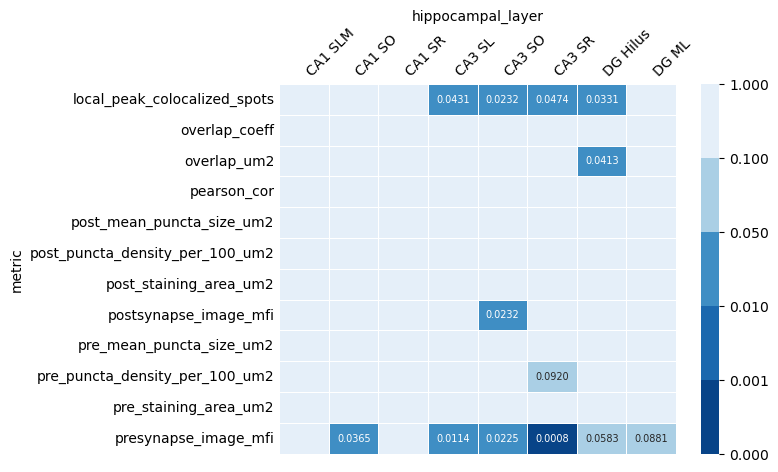

In [4]:
# myColors = ((0.8, 0.0, 0.0, 1.0), (0.0, 0.8, 0.0, 1.0), (0.0, 0.0, 0.8, 1.0))
# cmap = LinearSegmentedColormap.from_list('Custom', myColors, len(myColors))
# cmap = sns.color_palette('RdBu_r', n_colors = 5)

from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

mask = df_2 < 0.1
annotations = df_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


ax = sns.heatmap(data=df_2, annot=annotations, fmt = "", annot_kws={"fontsize": 7}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.show()

In [5]:
df_vglut2 = pd.read_csv("/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT2-PSD95_output_data/all_statistics.csv").set_index(['Unnamed: 0'])
df_vglut2.head(10)

,hippocampal_layer,metric,p_value,statistical significant?
Unnamed: 0,,,,
0,CA2 SP,overlap_um2,0.877503,No
1,CA2 SP,pearson_cor,0.272588,No
2,CA2 SP,overlap_coeff,0.634502,No
3,CA2 SP,local_peak_colocalized_spots,0.863586,No
4,CA2 SP,presynapse_image_mfi,0.134020,No
5,CA2 SP,postsynapse_image_mfi,0.542770,No
6,CA2 SP,pre_puncta_density_per_100_um2,0.959233,No
7,CA2 SP,post_puncta_density_per_100_um2,0.370260,No
8,CA2 SP,pre_staining_area_um2,0.790702,No


In [6]:
df_vglut2_2 = df_vglut2.pivot(index="metric", columns="hippocampal_layer", values="p_value")
df_vglut2_2.head(10)

hippocampal_layer,CA2 SP,Cortex L4,DG GC,Subiculum SP
metric,,,,
local_peak_colocalized_spots,0.863586,0.423528,0.717686,0.428943
overlap_coeff,0.634502,0.505680,0.173879,0.769035
overlap_um2,0.877503,0.692458,0.414461,0.935095
pearson_cor,0.272588,0.966465,0.042126,0.777575
post_mean_puncta_size_um2,0.802214,0.086714,0.471836,0.125796
post_puncta_density_per_100_um2,0.370260,0.914616,0.771345,0.203108
post_staining_area_um2,0.389825,0.741595,0.678492,0.024984
postsynapse_image_mfi,0.542770,0.524910,0.469391,0.297300
pre_mean_puncta_size_um2,0.655283,0.147142,0.807843,0.882214


In [ ]:
# filter out the postsynaptic metrics and the coloc metrics (not trustworhty)


/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_69500/1349620984.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = df_vglut2_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


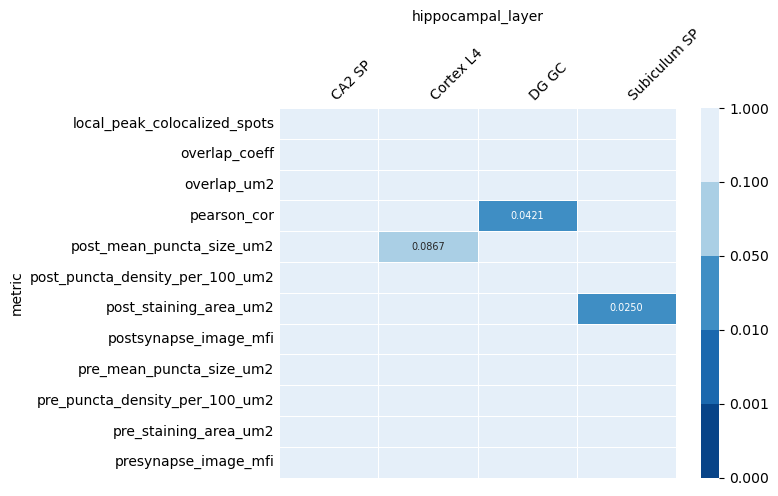

In [7]:
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

mask = df_vglut2_2 < 0.1
annotations = df_vglut2_2.applymap(lambda x: f'{x:.4f}' if x < 0.1 else '')


ax = sns.heatmap(data=df_vglut2_2, annot=annotations, fmt = "", annot_kws={"fontsize": 7}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=45, ha='left')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.show()

/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_69500/4220500059.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_2 = df_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_69500/4220500059.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')


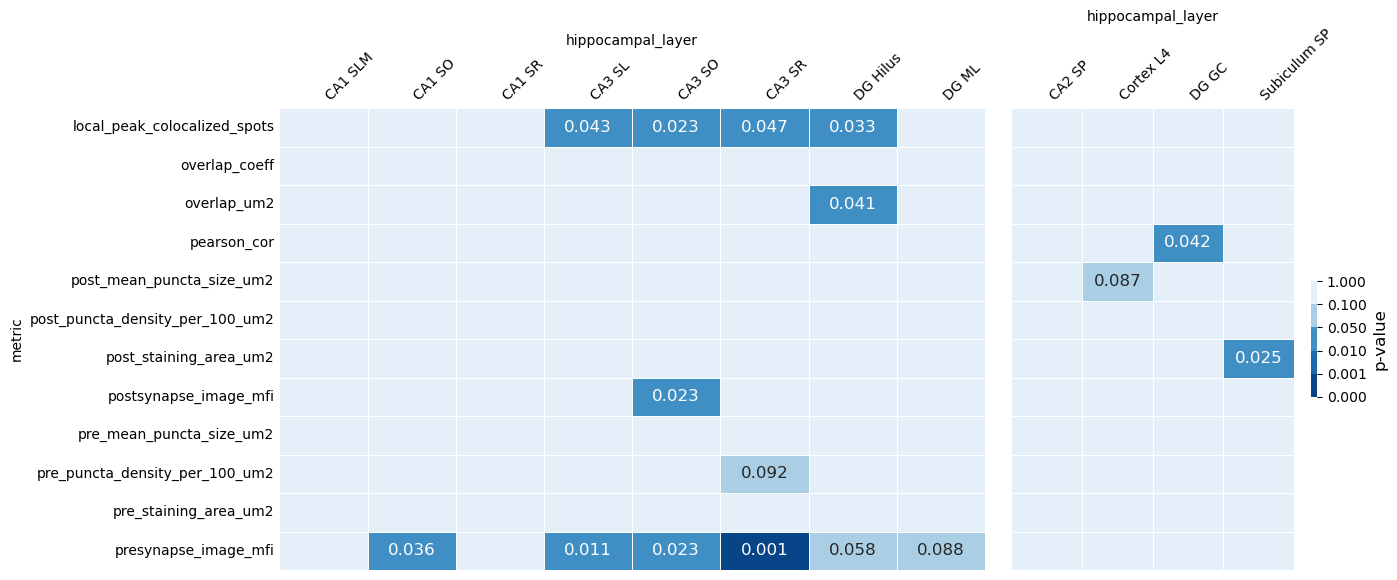

In [24]:
import matplotlib.gridspec as gridspec

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns

# Define a discrete colormap
cmap = ListedColormap(['#084488', '#1b68ae', '#3f8ec4', '#aacfe5', "#e5eff9"])
norm = BoundaryNorm([0, 0.001, 0.01, 0.05, 0.1, 1], cmap.N)

# Format annotations with 3 decimal places
annotations_2 = df_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')
annotations_3 = df_vglut2_2.applymap(lambda x: f'{x:.3f}' if x < 0.1 else '')

# Set up the figure and gridspec
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[len(df_2.columns), len(df_vglut2_2.columns)], wspace=0.05)

# Create the first heatmap
ax0 = plt.subplot(gs[0])
sns.heatmap(df_2, annot=annotations_2, fmt='', annot_kws={"fontsize": 12}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax0, cbar=False)
ax0.xaxis.set_label_position('top')
ax0.xaxis.tick_top()
ax0.tick_params(axis='x', length=0)
ax0.tick_params(axis='y', length=0)
plt.sca(ax0)
plt.xticks(rotation=45, ha='left')

# Create the second heatmap
ax1 = plt.subplot(gs[1])
heatmap = sns.heatmap(df_vglut2_2, annot=annotations_3, fmt='', annot_kws={"fontsize": 12}, linewidth=0.5, vmin=0, vmax=0.1, cmap=cmap, norm=norm, ax=ax1, cbar=True, yticklabels=False, cbar_kws={"shrink": 0.25} )
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.tick_params(axis='x', length=0)
ax1.tick_params(axis='y', length=0)
ax1.set_ylabel('')  # Remove the y-axis label
plt.sca(ax1)
plt.xticks(rotation=45, ha='left')

# Adjust colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)  # Smaller colorbar ticks
cbar.set_label('p-value', fontsize=12)  # Add title to colorbar

plt.show()

In [ ]:
#TODO: 
# - order the y labels from presynapse, postsynapse to coloc.
# - order the x axis labels
# - only include the presynapse values for VGLUT2-PSD95